# PV-Anlage
## Ablauf

Zuerst wollen wir die Daten aus der Datei lesen, damit wir sie verarbeiten können. Da wir  
die Vorteile von PyPlot, numpy und pandas sehen wollen, machen wir das hier im Schnelldurchlauf  
und gehen dann zum Lernen mehr in die Details!

```python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
```

Für kleine Datenmengen kann man diesen Code hier verwenden:

```python
with open("solar_data.csv", "r") as datei:
    zeilen = datei.readlines()
```

Zum Zeichnen ist das aber nicht so gut, pandas kann das besser. Außerdem sind das auch schon 
wieder über 50000 Zeilen und da ist schneller eben auch besser!

```python
data = pd.csv("DATEINAME", delimiter="SPALTENTRENNER")
```

Die Spalten sund durch Strichpunkte getrennt und enthalten folgende Daten:

1. Datum und Zeit
2. Aktuelle Leistung in kW
3. Ladestand absolut kWh
4. Ladestand prozentual

Lies diese Daten nun ein!

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# data = ... csv lesen ...
# data


In [8]:
data = pd.read_csv("solar_data.csv", delimiter=";",names=["Datum", "Leistung", "Ladung", "Prozent"])

In [9]:
data

,Datum,Leistung,Ladung,Prozent
0,2026-04-02 11:14:30,1068,5.632,22
1,2026-04-02 11:14:41,1035,5.632,22
2,2026-04-02 11:39:58,1793,5.888,23
3,2026-04-02 11:40:00,1796,5.888,23
4,2026-04-02 11:40:02,1796,5.888,23
...,...,...,...,...
53035,2026-05-09 14:37:02,5935,25.088,98
53036,2026-05-09 14:38:01,5925,25.088,98
53037,2026-05-09 14:39:01,5913,25.088,98
53038,2026-05-09 14:40:01,5940,25.088,98


Leider haben die Spalten in meiner Originaldatei keine beschrifteten Spaltenköpfe.  
Das können wir aber ändern!

Erweitere den Lade-Befehl um folgenden Eintrag:

```python
data = pd.read_csv(...,names=["Datum", "Leistung", "Ladung", "Prozent"])
```

Nun kannst du die Spalten auch einzeln anzeigen:

```python
data["Leistung"]

In [10]:
data["Leistung"]

0        1068
1        1035
2        1793
3        1796
4        1796
         ... 
53035    5935
53036    5925
53037    5913
53038    5940
53039    5942
Name: Leistung, Length: 53040, dtype: int64

In [ ]:
Theoretisch geht nun bereits folgender Code - allerdings mit unbefriedigendem Ergebnis!

```python
plt.plot(data["Datum"], data["Leistung"])
```

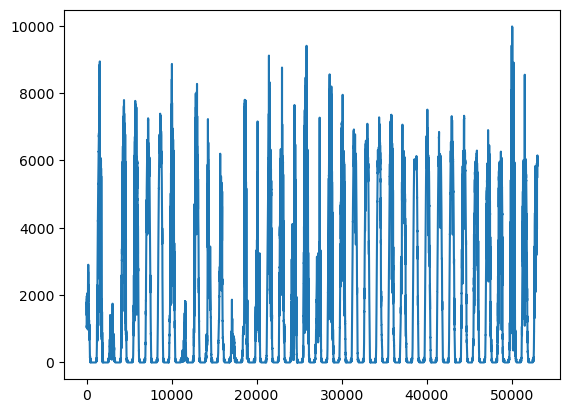

In [13]:
plt.plot(data.index, data["Leistung"])

Die x-Achse ist natürlich **nicht** das Datum, sondern die Zeilennummer!  




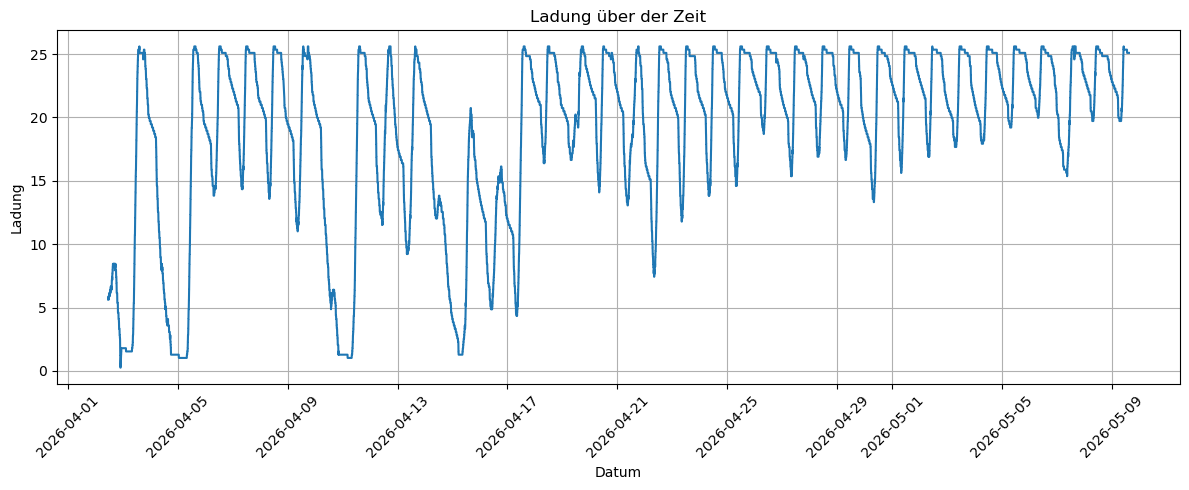

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV-Datei einlesen
df = pd.read_csv(
    "solar_data.csv",
    sep=";",
    names=["Datum", "Leistung", "Ladung", "Prozent"],
    parse_dates=["Datum"]
)

# Datum als Index setzen (optional, aber praktisch)
df.set_index("Datum", inplace=True)

# Plot erstellen
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["Ladung"])

# Beschriftungen
plt.xlabel("Datum")
plt.ylabel("Ladung")
plt.title("Ladung über der Zeit")

# Gitternetz
plt.grid(True)

# Datumsbeschriftung schöner darstellen
plt.xticks(rotation=45)

# Layout anpassen
plt.tight_layout()

# Anzeigen
plt.show()